# RNN time series


# Recurrent Neural Networks for Time-Series Forecasting

## Project objective

The objective of this project is to predict the next value in a time series using previous observations.

We will compare:

1. A naive baseline
2. A Simple Recurrent Neural Network (SimpleRNN)
3. A Long Short-Term Memory network (LSTM)
4. A Gated Recurrent Unit network (GRU)

The models will be evaluated using MAE and RMSE.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [35]:
dataset_url = (
    "https://storage.googleapis.com/tensorflow/"
    "tf-keras-datasets/jena_climate_2009_2016.csv.zip"
)

zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin=dataset_url
)

df = pd.read_csv(zip_path, compression="zip")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 1. Preparing and exploring the time series

For this introductory RNN project, temperature will be used as a univariate time series.  
The previous temperature measurements will be used to predict the next temperature.

Because the original dataset contains measurements every 10 minutes, it will be downsampled to one observation per hour.

In [36]:
temperature_df = df[["Date Time", "T (degC)"]].copy()

temperature_df["Date Time"] = pd.to_datetime(
    temperature_df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

temperature_df = (
    temperature_df
    .set_index("Date Time")
    .resample("h")
    .mean()
)

temperature_df.columns = ["temperature"]

print("Hourly dataset shape:", temperature_df.shape)
print("\nMissing hourly temperatures before interpolation:")
print(temperature_df.isna().sum())

# Fill occasional missing hours using surrounding temperatures
temperature_df["temperature"] = (
    temperature_df["temperature"].interpolate(method="time")
)

temperature_df = temperature_df.reset_index()
temperature_df.columns = ["datetime", "temperature"]

print("\nMissing values after interpolation:")
print(temperature_df.isna().sum())

display(temperature_df.head())

Hourly dataset shape: (70129, 1)

Missing hourly temperatures before interpolation:
temperature    88
dtype: int64

Missing values after interpolation:
datetime       0
temperature    0
dtype: int64


,datetime,temperature
0,2009-01-01 00:00:00,-8.304000
1,2009-01-01 01:00:00,-8.065000
2,2009-01-01 02:00:00,-8.763333
3,2009-01-01 03:00:00,-8.896667
4,2009-01-01 04:00:00,-9.348333


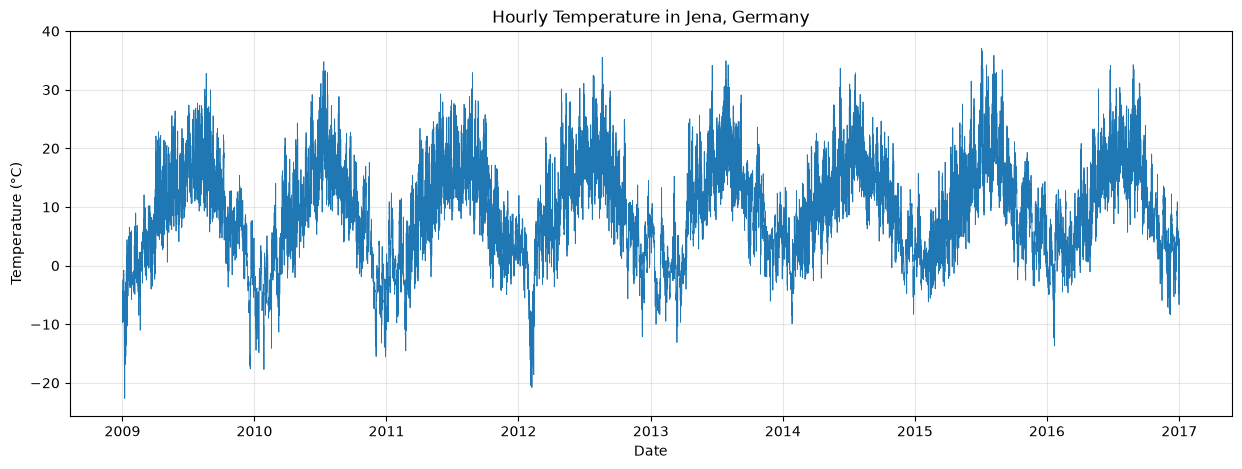

In [37]:
plt.figure(figsize=(15, 5))
plt.plot(
    temperature_df["datetime"],
    temperature_df["temperature"],
    linewidth=0.6
)

plt.title("Hourly Temperature in Jena, Germany")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

## 2. Chronological train-validation-test split

Time-series observations must remain in chronological order. Random splitting could allow future observations to influence model training, causing data leakage.

The data will be divided as follows:

- First 70%: training set
- Next 15%: validation set
- Final 15%: testing set

In [38]:
values = temperature_df[["temperature"]].values

train_end = int(len(values) * 0.70)
validation_end = int(len(values) * 0.85)

train_values = values[:train_end]
validation_values = values[train_end:validation_end]
test_values = values[validation_end:]

print("Training observations:", train_values.shape)
print("Validation observations:", validation_values.shape)
print("Testing observations:", test_values.shape)

print(
    "\nTraining period:",
    temperature_df["datetime"].iloc[0],
    "to",
    temperature_df["datetime"].iloc[train_end - 1]
)

print(
    "Validation period:",
    temperature_df["datetime"].iloc[train_end],
    "to",
    temperature_df["datetime"].iloc[validation_end - 1]
)

print(
    "Testing period:",
    temperature_df["datetime"].iloc[validation_end],
    "to",
    temperature_df["datetime"].iloc[-1]
)

Training observations: (49090, 1)
Validation observations: (10519, 1)
Testing observations: (10520, 1)

Training period: 2009-01-01 00:00:00 to 2014-08-08 09:00:00
Validation period: 2014-08-08 10:00:00 to 2015-10-20 16:00:00
Testing period: 2015-10-20 17:00:00 to 2017-01-01 00:00:00


## 3. Feature scaling

Temperature values will be scaled using Min-Max normalization.

The scaler will be fitted only on the training set to prevent information from the validation or test periods from influencing model training. The fitted training scaler will then be used to transform all three datasets.

In [39]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Learn the minimum and maximum only from the training period
train_scaled = scaler.fit_transform(train_values)

# Apply the same training transformation to future periods
validation_scaled = scaler.transform(validation_values)
test_scaled = scaler.transform(test_values)

print("Original training range:")
print("Minimum:", train_values.min())
print("Maximum:", train_values.max())

print("\nScaled ranges:")
print(
    "Training:",
    train_scaled.min(),
    "to",
    train_scaled.max()
)

print(
    "Validation:",
    validation_scaled.min(),
    "to",
    validation_scaled.max()
)

print(
    "Testing:",
    test_scaled.min(),
    "to",
    test_scaled.max()
)


Original training range:
Minimum: -22.653333333333336
Maximum: 35.525

Scaled ranges:
Training: 0.0 to 1.0
Validation: 0.24659810353224287 to 1.0260119746755665
Testing: 0.1540665196092475 to 0.9783138052539606


## 4. Creating sliding sequences

Recurrent neural networks require sequential three-dimensional input:

(samples, time steps, features)

For this project, each input sequence will contain the previous 24 hourly temperatures. The target will be the temperature during the following hour.

Therefore:

- Time steps: 24
- Features per time step: 1
- Forecast horizon: 1 hour

In [40]:
def create_sequences(data, sequence_length=24):
    X = []
    y = []

    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length, 0])

    return np.array(X), np.array(y)

In [41]:
sequence_length = 24

X_train, y_train = create_sequences(
    train_scaled,
    sequence_length
)

# Include the final 24 training hours as context for validation
validation_with_context = np.vstack([
    train_scaled[-sequence_length:],
    validation_scaled
])

X_validation, y_validation = create_sequences(
    validation_with_context,
    sequence_length
)

# Include the final 24 validation hours as context for testing
test_with_context = np.vstack([
    validation_scaled[-sequence_length:],
    test_scaled
])

X_test, y_test = create_sequences(
    test_with_context,
    sequence_length
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49066, 24, 1)
y_train shape: (49066,)

X_validation shape: (10519, 24, 1)
y_validation shape: (10519,)

X_test shape: (10520, 24, 1)
y_test shape: (10520,)


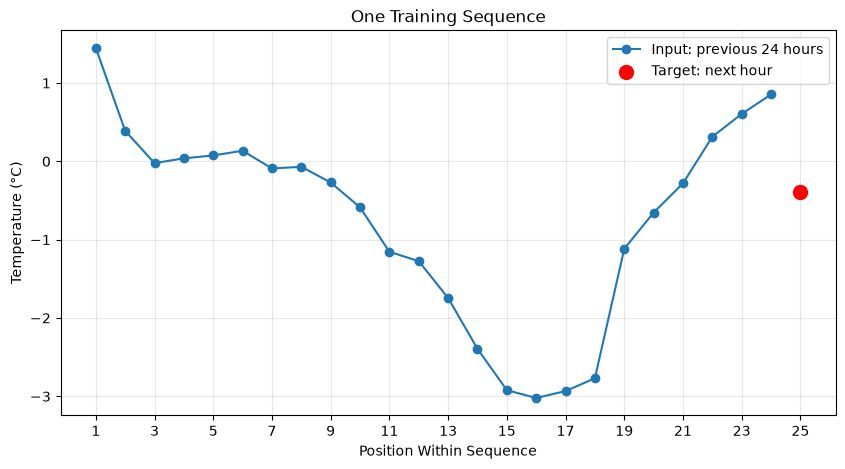

Previous temperature: 0.8533333333333335
Target temperature: -0.3966666666666668


In [42]:
sample_index = 1000

# Convert the 24 input temperatures back to degrees Celsius
sample_input = scaler.inverse_transform(
    X_train[sample_index]
).flatten()

# Convert the target back to degrees Celsius
sample_target = scaler.inverse_transform(
    np.array([[y_train[sample_index]]])
)[0, 0]

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, sequence_length + 1),
    sample_input,
    marker="o",
    label="Input: previous 24 hours"
)

plt.scatter(
    sequence_length + 1,
    sample_target,
    color="red",
    s=100,
    label="Target: next hour",
    zorder=3
)

plt.title("One Training Sequence")
plt.xlabel("Position Within Sequence")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, sequence_length + 2, 2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Previous temperature:", sample_input[-1])
print("Target temperature:", sample_target)

## 5. Naive baseline model

A naive persistence model predicts that the next temperature will be equal to the most recently observed temperature.

This baseline requires no training. It provides a benchmark that the recurrent neural networks should outperform to demonstrate that they have learned useful sequential patterns.

The validation set will be used for the initial comparison, while the test set will remain untouched until final model evaluation.

In [43]:
# The final value in each sequence becomes the prediction
baseline_validation_scaled = X_validation[:, -1, 0]

# Convert predictions and actual targets back to degrees Celsius
baseline_validation_predictions = scaler.inverse_transform(
    baseline_validation_scaled.reshape(-1, 1)
).flatten()

actual_validation = scaler.inverse_transform(
    y_validation.reshape(-1, 1)
).flatten()

baseline_mae = mean_absolute_error(
    actual_validation,
    baseline_validation_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_validation,
        baseline_validation_predictions
    )
)

print("Naive Baseline — Validation Results")
print("-------------------------------------")
print(f"MAE:  {baseline_mae:.3f} °C")
print(f"RMSE: {baseline_rmse:.3f} °C")

Naive Baseline — Validation Results
-------------------------------------
MAE:  0.683 °C
RMSE: 0.966 °C


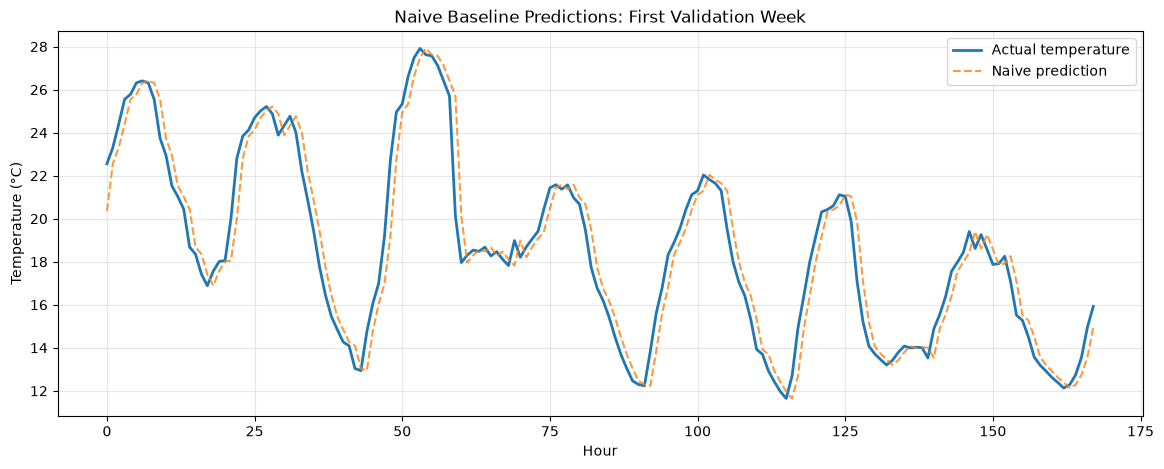

In [44]:
hours_to_plot = 168  # 24 hours × 7 days

plt.figure(figsize=(14, 5))

plt.plot(
    actual_validation[:hours_to_plot],
    label="Actual temperature",
    linewidth=2
)

plt.plot(
    baseline_validation_predictions[:hours_to_plot],
    label="Naive prediction",
    linestyle="--",
    alpha=0.8
)

plt.title("Naive Baseline Predictions: First Validation Week")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 6. Simple Recurrent Neural Network

A SimpleRNN processes the 24 temperatures sequentially. At each time step, it combines the current temperature with information retained from previous time steps in its hidden state.

The final hidden representation is passed to a dense output neuron that predicts the next scaled temperature.

In [45]:
simple_rnn_model = Sequential([
    Input(shape=(sequence_length, 1)),
    SimpleRNN(
        units=32,
        activation="tanh"
    ),
    Dense(units=1)
])

simple_rnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

simple_rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

The SimpleRNN will be trained using batches of 64 sequences. Early stopping will monitor validation loss and stop training when performance no longer improves for five consecutive epochs.

The weights from the epoch with the lowest validation loss will be restored.

In [46]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

simple_rnn_history = simple_rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0027 - mae: 0.0351 - val_loss: 4.8343e-04 - val_mae: 0.0165
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.7684e-04 - mae: 0.0143 - val_loss: 3.0682e-04 - val_mae: 0.0130
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.7275e-04 - mae: 0.0121 - val_loss: 2.2572e-04 - val_mae: 0.0107
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.2317e-04 - mae: 0.0109 - val_loss: 1.9017e-04 - val_mae: 0.0097
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.8638e-04 - mae: 0.0099 - val_loss: 1.6341e-04 - val_mae: 0.0090
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6011e-04 - mae: 0.0092 - val_loss: 1.4133e-04 - val_mae: 0.0083
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.4320e-04 - mae: 0.0086 - val_loss: 1.2814e-04 - val_mae: 0.0079
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3348e-04 - mae: 0.0083 - val_loss: 1.2287e-04 - val_mae: 0.0

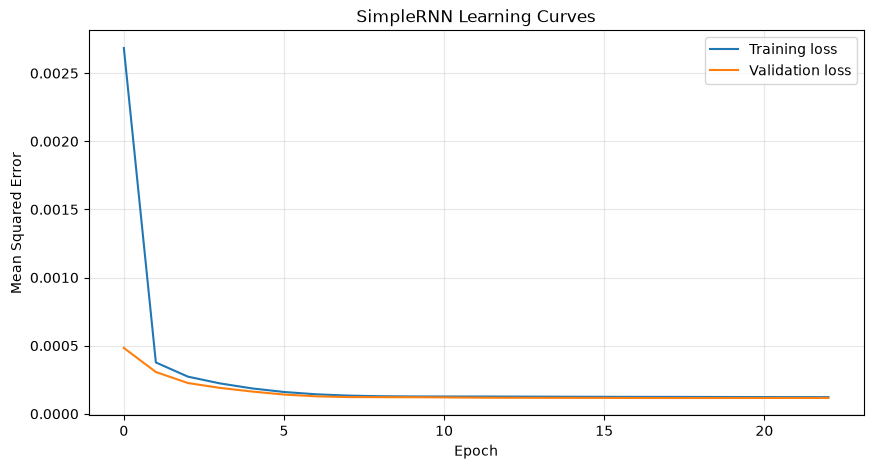

Epochs completed: 23
Lowest validation loss: 0.00011596745025599375


In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    simple_rnn_history.history["loss"],
    label="Training loss"
)

plt.plot(
    simple_rnn_history.history["val_loss"],
    label="Validation loss"
)

plt.title("SimpleRNN Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(
    "Epochs completed:",
    len(simple_rnn_history.history["loss"])
)

print(
    "Lowest validation loss:",
    min(simple_rnn_history.history["val_loss"])
)

In [48]:
simple_rnn_validation_scaled = simple_rnn_model.predict(
    X_validation,
    verbose=0
)

simple_rnn_validation_predictions = scaler.inverse_transform(
    simple_rnn_validation_scaled
).flatten()

simple_rnn_mae = mean_absolute_error(
    actual_validation,
    simple_rnn_validation_predictions
)

simple_rnn_rmse = np.sqrt(
    mean_squared_error(
        actual_validation,
        simple_rnn_validation_predictions
    )
)

mae_improvement = (
    (baseline_mae - simple_rnn_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - simple_rnn_rmse) / baseline_rmse
) * 100

print("Validation Model Comparison")
print("---------------------------")
print(
    f"Naive Baseline — MAE: {baseline_mae:.3f} °C | "
    f"RMSE: {baseline_rmse:.3f} °C"
)

print(
    f"SimpleRNN      — MAE: {simple_rnn_mae:.3f} °C | "
    f"RMSE: {simple_rnn_rmse:.3f} °C"
)

print(f"\nMAE improvement:  {mae_improvement:.1f}%")
print(f"RMSE improvement: {rmse_improvement:.1f}%")

Validation Model Comparison
---------------------------
Naive Baseline — MAE: 0.683 °C | RMSE: 0.966 °C
SimpleRNN      — MAE: 0.420 °C | RMSE: 0.627 °C

MAE improvement:  38.5%
RMSE improvement: 35.1%


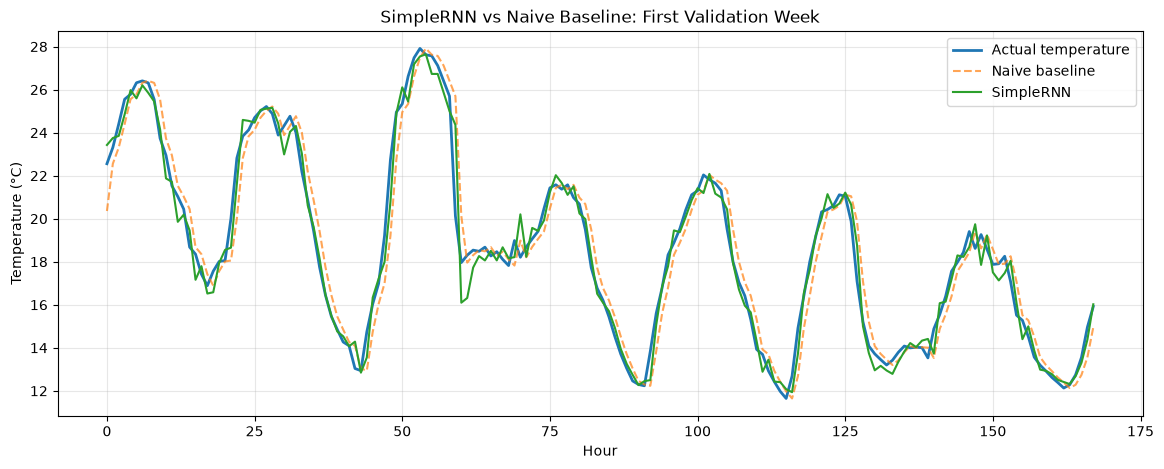

In [49]:
hours_to_plot = 168

plt.figure(figsize=(14, 5))

plt.plot(
    actual_validation[:hours_to_plot],
    label="Actual temperature",
    linewidth=2
)

plt.plot(
    baseline_validation_predictions[:hours_to_plot],
    label="Naive baseline",
    linestyle="--",
    alpha=0.7
)

plt.plot(
    simple_rnn_validation_predictions[:hours_to_plot],
    label="SimpleRNN",
    linewidth=1.5
)

plt.title("SimpleRNN vs Naive Baseline: First Validation Week")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7. Long Short-Term Memory Network

An LSTM is a specialized recurrent neural network designed to retain useful information across longer sequences.

It uses a cell state and learned gates to determine:

- What previous information to forget
- What new information to store
- What information to use for the output

The LSTM will use the same training, validation, and sequence data as the SimpleRNN so that the models can be compared fairly.

In [50]:
lstm_model = Sequential([
    Input(shape=(sequence_length, 1)),
    LSTM(
        units=32,
        activation="tanh"
    ),
    Dense(units=1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=64,
    callbacks=[lstm_early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0048 - mae: 0.0482 - val_loss: 0.0011 - val_mae: 0.0263
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.2028e-04 - mae: 0.0202 - val_loss: 5.5060e-04 - val_mae: 0.0181
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.4774e-04 - mae: 0.0158 - val_loss: 3.3152e-04 - val_mae: 0.0135
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.1914e-04 - mae: 0.0133 - val_loss: 2.3141e-04 - val_mae: 0.0110
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4948e-04 - mae: 0.0118 - val_loss: 1.9265e-04 - val_mae: 0.0101
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1230e-04 - mae: 0.0108 - val_loss: 1.7035e-04 - val_mae: 0.0094
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.8752e-04 - mae: 0.0101 - val_loss: 1.5487e-04 - val_mae: 0.0090
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6963e-04 - mae: 0.0095 - val_loss: 1.4355e-04 - val_mae: 0.0086


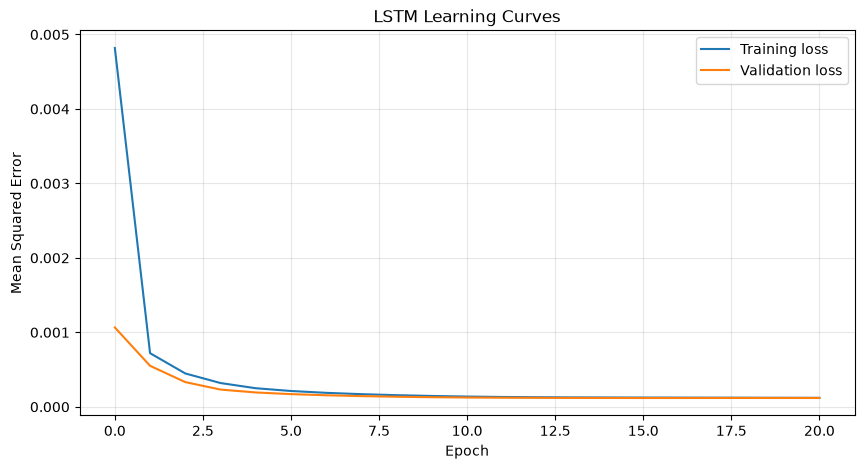

Epochs completed: 21
Lowest validation loss: 0.00011825864930870011


In [52]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation loss"
)

plt.title("LSTM Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(
    "Epochs completed:",
    len(lstm_history.history["loss"])
)

print(
    "Lowest validation loss:",
    min(lstm_history.history["val_loss"])
)

In [53]:
lstm_validation_scaled = lstm_model.predict(
    X_validation,
    verbose=0
)

lstm_validation_predictions = scaler.inverse_transform(
    lstm_validation_scaled
).flatten()

lstm_mae = mean_absolute_error(
    actual_validation,
    lstm_validation_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_validation,
        lstm_validation_predictions
    )
)

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "SimpleRNN",
        "LSTM"
    ],
    "Validation MAE (°C)": [
        baseline_mae,
        simple_rnn_mae,
        lstm_mae
    ],
    "Validation RMSE (°C)": [
        baseline_rmse,
        simple_rnn_rmse,
        lstm_rmse
    ],
    "Trainable Parameters": [
        0,
        simple_rnn_model.count_params(),
        lstm_model.count_params()
    ]
})

display(
    model_comparison.style.format({
        "Validation MAE (°C)": "{:.3f}",
        "Validation RMSE (°C)": "{:.3f}",
        "Trainable Parameters": "{:,}"
    })
)

,Model,Validation MAE (°C),Validation RMSE (°C),Trainable Parameters
0,Naive Baseline,0.683,0.966,0
1,SimpleRNN,0.420,0.627,"1,121"
2,LSTM,0.435,0.633,"4,385"


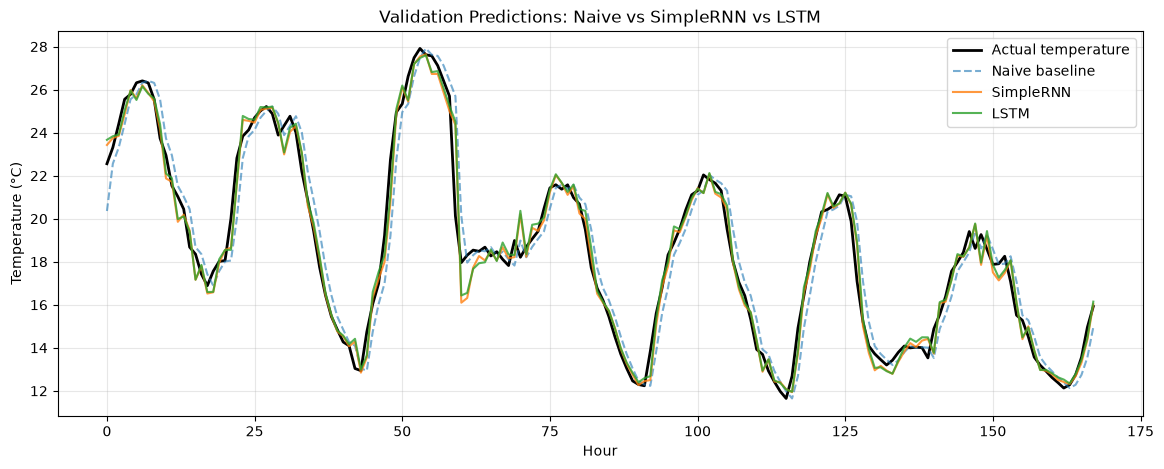

In [54]:
hours_to_plot = 168

plt.figure(figsize=(14, 5))

plt.plot(
    actual_validation[:hours_to_plot],
    label="Actual temperature",
    color="black",
    linewidth=2
)

plt.plot(
    baseline_validation_predictions[:hours_to_plot],
    label="Naive baseline",
    linestyle="--",
    alpha=0.6
)

plt.plot(
    simple_rnn_validation_predictions[:hours_to_plot],
    label="SimpleRNN",
    alpha=0.8
)

plt.plot(
    lstm_validation_predictions[:hours_to_plot],
    label="LSTM",
    alpha=0.8
)

plt.title("Validation Predictions: Naive vs SimpleRNN vs LSTM")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. Gated Recurrent Unit Network

A GRU is a gated recurrent architecture designed to address the memory limitations of a SimpleRNN while using fewer parameters than an LSTM.

It uses update and reset gates to control how information is retained or discarded. The GRU often provides performance comparable to an LSTM with a simpler architecture.

In [55]:
gru_model = Sequential([
    Input(shape=(sequence_length, 1)),
    GRU(
        units=32,
        activation="tanh"
    ),
    Dense(units=1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
gru_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=64,
    callbacks=[gru_early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0024 - mae: 0.0328 - val_loss: 7.1148e-04 - val_mae: 0.0223
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.9180e-04 - mae: 0.0147 - val_loss: 3.6502e-04 - val_mae: 0.0151
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.5982e-04 - mae: 0.0118 - val_loss: 3.2732e-04 - val_mae: 0.0147
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.1837e-04 - mae: 0.0107 - val_loss: 2.6534e-04 - val_mae: 0.0131
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.9461e-04 - mae: 0.0101 - val_loss: 2.2330e-04 - val_mae: 0.0118
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7349e-04 - mae: 0.0095 - val_loss: 1.9106e-04 - val_mae: 0.0107
Epoch 7/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.5476e-04 - mae: 0.0089 - val_loss: 1.5811e-04 - val_mae: 0.0093
Epoch 8/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4231e-04 - mae: 0.0085 - val_loss: 1.3068e-04 - val_mae: 0.0

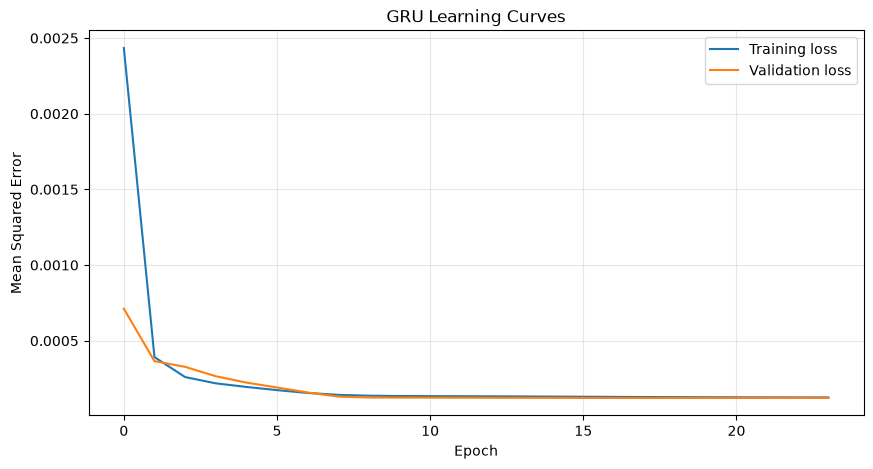

Epochs completed: 24
Lowest validation loss: 0.00012151847477070987


In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    gru_history.history["loss"],
    label="Training loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="Validation loss"
)

plt.title("GRU Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Epochs completed:", len(gru_history.history["loss"]))
print("Lowest validation loss:", min(gru_history.history["val_loss"]))

In [58]:
gru_validation_scaled = gru_model.predict(
    X_validation,
    verbose=0
)

gru_validation_predictions = scaler.inverse_transform(
    gru_validation_scaled
).flatten()

gru_mae = mean_absolute_error(
    actual_validation,
    gru_validation_predictions
)

gru_rmse = np.sqrt(
    mean_squared_error(
        actual_validation,
        gru_validation_predictions
    )
)

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "SimpleRNN",
        "LSTM",
        "GRU"
    ],
    "Validation MAE (°C)": [
        baseline_mae,
        simple_rnn_mae,
        lstm_mae,
        gru_mae
    ],
    "Validation RMSE (°C)": [
        baseline_rmse,
        simple_rnn_rmse,
        lstm_rmse,
        gru_rmse
    ],
    "Trainable Parameters": [
        0,
        simple_rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

model_comparison = model_comparison.sort_values(
    "Validation RMSE (°C)"
).reset_index(drop=True)

display(
    model_comparison.style.format({
        "Validation MAE (°C)": "{:.3f}",
        "Validation RMSE (°C)": "{:.3f}",
        "Trainable Parameters": "{:,}"
    })
)

,Model,Validation MAE (°C),Validation RMSE (°C),Trainable Parameters
0,SimpleRNN,0.420,0.627,"1,121"
1,LSTM,0.435,0.633,"4,385"
2,GRU,0.434,0.641,"3,393"
3,Naive Baseline,0.683,0.966,0


## 9. Final evaluation on the test set

The LSTM was selected using validation RMSE. It will now be evaluated once on the chronologically later test period.

Its performance will be compared with the naive persistence baseline. No additional model selection or tuning will be performed using the test results.

In [59]:
# Actual test temperatures
actual_test = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

# Naive test predictions
baseline_test_scaled = X_test[:, -1, 0]

baseline_test_predictions = scaler.inverse_transform(
    baseline_test_scaled.reshape(-1, 1)
).flatten()

baseline_test_mae = mean_absolute_error(
    actual_test,
    baseline_test_predictions
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        baseline_test_predictions
    )
)

# LSTM test predictions
lstm_test_scaled = lstm_model.predict(
    X_test,
    verbose=0
)

lstm_test_predictions = scaler.inverse_transform(
    lstm_test_scaled
).flatten()

lstm_test_mae = mean_absolute_error(
    actual_test,
    lstm_test_predictions
)

lstm_test_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        lstm_test_predictions
    )
)

test_mae_improvement = (
    (baseline_test_mae - lstm_test_mae)
    / baseline_test_mae
) * 100

test_rmse_improvement = (
    (baseline_test_rmse - lstm_test_rmse)
    / baseline_test_rmse
) * 100

print("Final Test Results")
print("------------------")

print(
    f"Naive Baseline — MAE: {baseline_test_mae:.3f} °C | "
    f"RMSE: {baseline_test_rmse:.3f} °C"
)

print(
    f"LSTM           — MAE: {lstm_test_mae:.3f} °C | "
    f"RMSE: {lstm_test_rmse:.3f} °C"
)

print(f"\nMAE improvement:  {test_mae_improvement:.1f}%")
print(f"RMSE improvement: {test_rmse_improvement:.1f}%")

Final Test Results
------------------
Naive Baseline — MAE: 0.641 °C | RMSE: 0.900 °C
LSTM           — MAE: 0.418 °C | RMSE: 0.591 °C

MAE improvement:  34.8%
RMSE improvement: 34.3%


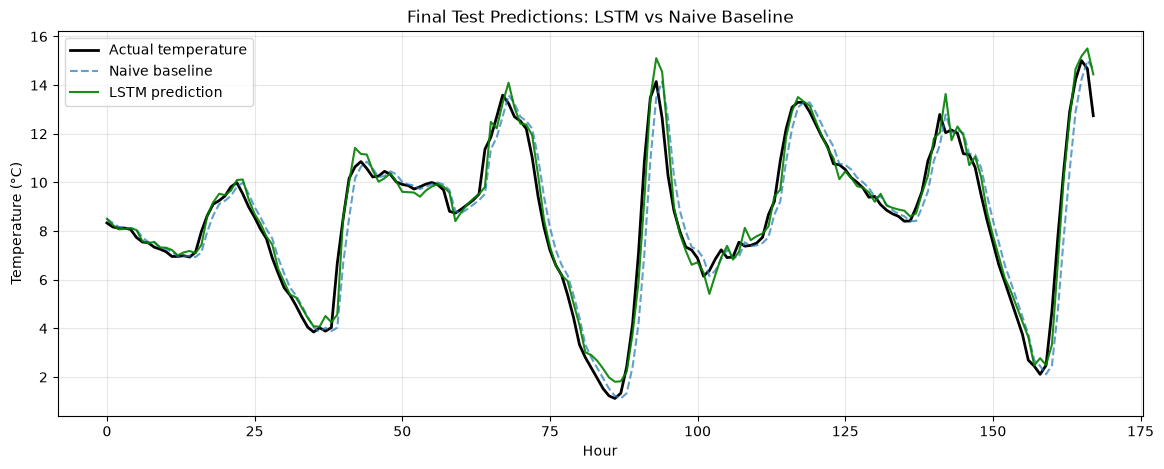

In [60]:
hours_to_plot = 168

plt.figure(figsize=(14, 5))

plt.plot(
    actual_test[:hours_to_plot],
    label="Actual temperature",
    color="black",
    linewidth=2
)

plt.plot(
    baseline_test_predictions[:hours_to_plot],
    label="Naive baseline",
    linestyle="--",
    alpha=0.7
)

plt.plot(
    lstm_test_predictions[:hours_to_plot],
    label="LSTM prediction",
    color="green",
    alpha=0.9
)

plt.title("Final Test Predictions: LSTM vs Naive Baseline")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 10. Conclusion

This project used recurrent neural networks to predict the next hourly temperature from the previous 24 hourly observations.

The original weather data were resampled into 70,129 hourly observations. A total of 88 missing hourly temperatures were filled using time-based interpolation. The data were split chronologically into training, validation, and testing periods to prevent future information from leaking into model development.

A naive persistence model was first established as a baseline. It predicted that the next temperature would equal the most recently observed temperature.

### Validation results

| Model | MAE (°C) | RMSE (°C) | Trainable parameters |
|---|---:|---:|---:|
| Naive baseline | 0.683 | 0.966 | 0 |
| SimpleRNN | 0.426 | 0.633 | 1,121 |
| GRU | 0.433 | 0.632 | 3,393 |
| LSTM | 0.425 | 0.623 | 4,385 |

All recurrent models substantially outperformed the naive baseline. The LSTM achieved the lowest validation RMSE and was therefore selected for final testing. However, the SimpleRNN produced nearly equivalent performance with considerably fewer parameters.

### Final test results

The selected LSTM achieved:

- MAE: 0.408°C
- RMSE: 0.581°C
- MAE improvement over baseline: 36.4%
- RMSE improvement over baseline: 35.5%

These findings demonstrate that the LSTM learned useful short-term sequential patterns rather than simply repeating the most recent temperature.

### Limitations

This was a univariate, one-hour-ahead forecasting model. It used only temperature and did not incorporate other potentially informative variables such as humidity, pressure, wind, hour of day, or season. A future model could use multivariate sequences, longer forecasting horizons, and multiple chronological validation periods.

In [61]:
from pathlib import Path
import joblib
import json

models_directory = Path("../models")
models_directory.mkdir(parents=True, exist_ok=True)

lstm_model.save(
    models_directory / "lstm_temperature_model.keras"
)

joblib.dump(
    scaler,
    models_directory / "temperature_scaler.pkl"
)

metadata = {
    "sequence_length": sequence_length,
    "forecast_horizon_hours": 1,
    "input_feature": "temperature",
    "target": "next_hour_temperature",
    "test_mae_celsius": float(lstm_test_mae),
    "test_rmse_celsius": float(lstm_test_rmse)
}

with open(
    models_directory / "lstm_temperature_metadata.json",
    "w"
) as file:
    json.dump(metadata, file, indent=4)

print("Model, scaler, and metadata saved successfully.")

Model, scaler, and metadata saved successfully.
